# Day 6 — Logistic Regression (Titanic) 🚢
**Kaj:** passenger **Survived** (0/1) predict kora. Supervised · Classification.

> ⚙️ **Kernel:** upore-daane kernel picker theke **"Python (LAB-FINAL-2)"** select koro (na hole pandas/sklearn import fail korbe).
>
> ▶️ Cell run: `Shift+Enter`. Sob ekbare: menu **Run → Run All Cells**.
>
> 📝 Practice tip: ekbar niche porjonto run koro, tarpor cell muche nijer hate abar likhe dekho.

## 1. Import + data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
train = pd.read_csv('titanic_train.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. EDA — missing data o distribution
Heatmap-e holud daggula = missing. Age ~20% missing (fill korbo), Cabin onek missing (drop korbo).

<Axes: >

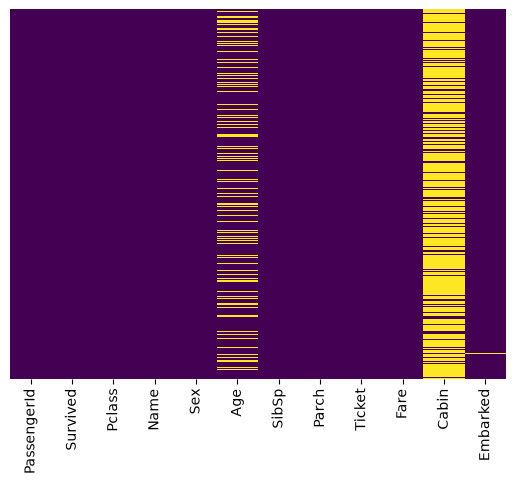

In [3]:
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

<Axes: xlabel='Survived', ylabel='count'>

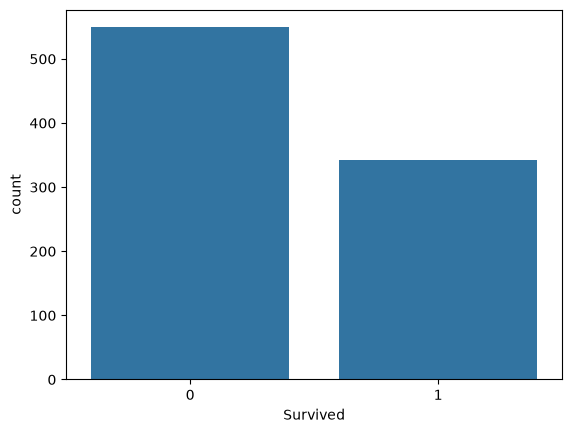

In [4]:
sns.countplot(x='Survived', data=train)

<Axes: xlabel='Survived', ylabel='count'>

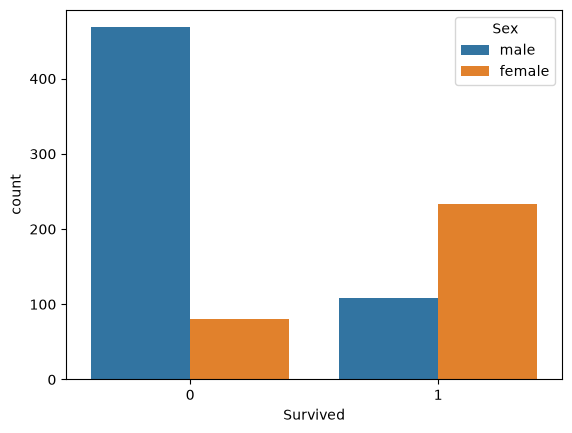

In [5]:
sns.countplot(x='Survived', hue='Sex', data=train)     # beshi male mara geche

<Axes: xlabel='Survived', ylabel='count'>

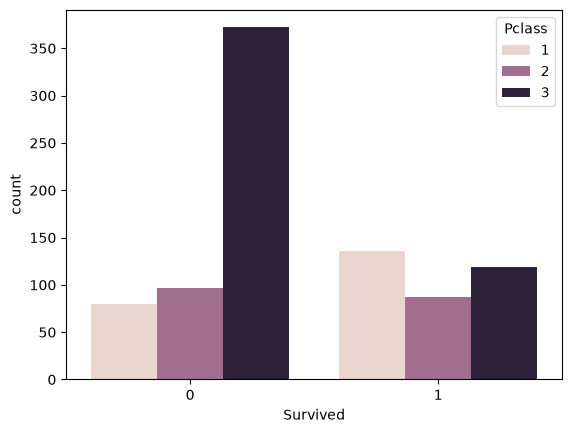

In [6]:
sns.countplot(x='Survived', hue='Pclass', data=train)  # class 3 e death beshi

<Axes: xlabel='Age', ylabel='Count'>

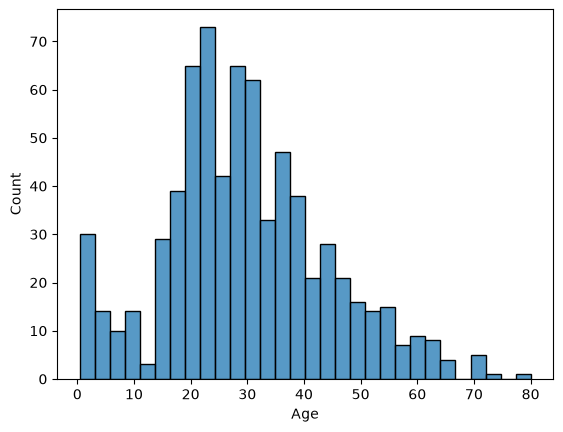

In [7]:
sns.histplot(train['Age'].dropna(), bins=30)   # lab: sns.displot

## 3. Data cleaning (ei day-er asol part)
**impute_age:** Age missing hole Pclass onujayi boshao (class 1→37, 2→29, 3→24) — boxplot dekhe.

<Axes: xlabel='Pclass', ylabel='Age'>

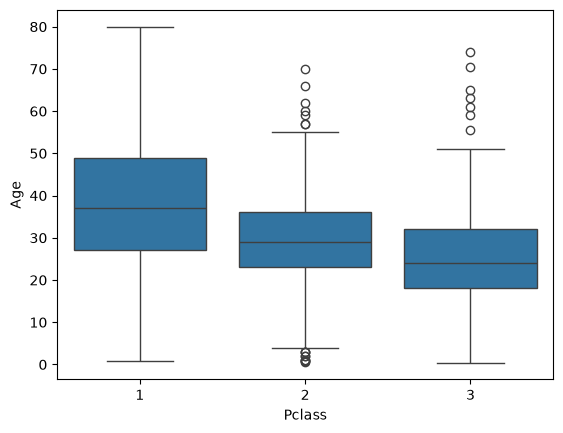

In [8]:
sns.boxplot(x='Pclass', y='Age', data=train)

In [9]:
def impute_age(cols):
    Age = cols.iloc[0]
    Pclass = cols.iloc[1]
    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age

train['Age'] = train[['Age','Pclass']].apply(impute_age, axis=1)

<Axes: >

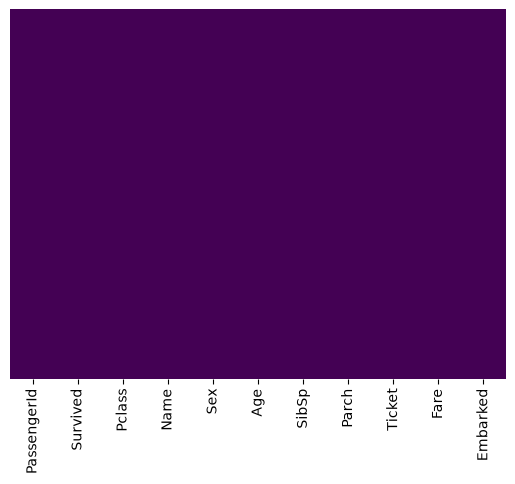

In [10]:
train.drop('Cabin', axis=1, inplace=True)   # onek NaN -> drop
train.dropna(inplace=True)                  # baki NaN row (Embarked) drop
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')  # ekhon clean

## 4. Categorical -> dummy variables
Model text nite pare na. `get_dummies(drop_first=True)` -> 0/1 column; drop_first = dummy variable trap edaj.

In [11]:
sex = pd.get_dummies(train['Sex'], drop_first=True)        # -> 'male' (0/1)
embark = pd.get_dummies(train['Embarked'], drop_first=True) # -> 'Q','S'
train.drop(['Sex','Embarked','Name','Ticket'], axis=1, inplace=True)
train = pd.concat([train, sex, embark], axis=1)
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


## 5. Train/Test split + model train

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    train.drop('Survived', axis=1), train['Survived'],
    test_size=0.30, random_state=101)

In [13]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression(solver='lbfgs', max_iter=1000)
logmodel.fit(X_train, y_train)
predictions = logmodel.predict(X_test)

## 6. Evaluation — classification metrics
`classification_report` = precision/recall/f1/accuracy. `confusion_matrix` = [[TN, FP],[FN, TP]].

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86       163
           1       0.84      0.68      0.75       104

    accuracy                           0.82       267
   macro avg       0.83      0.80      0.81       267
weighted avg       0.83      0.82      0.82       267



In [15]:
print(confusion_matrix(y_test, predictions))

[[149  14]
 [ 33  71]]


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print('Accuracy :', accuracy_score(y_test, predictions))
print('Precision:', precision_score(y_test, predictions))
print('Recall   :', recall_score(y_test, predictions))
print('F1       :', f1_score(y_test, predictions))

Accuracy : 0.8239700374531835
Precision: 0.8352941176470589
Recall   : 0.6826923076923077
F1       : 0.7513227513227513


✅ **Sesh.** Day 5-er sathe parthokko:  model = **LogisticRegression**, metric = **classification_report/confusion_matrix** (regression-er MAE/RMSE noy).